In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                            classification_report,
                            confusion_matrix)

import pickle

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
matches    = pd.read_csv('../data/processed/matches_clean.csv')
deliveries = pd.read_csv('../data/processed/deliveries_clean.csv')
print(f"Matches: {matches.shape}")
print(f"Deliveries: {deliveries.shape}")

Matches: (1095, 21)
Deliveries: (260920, 17)


In [3]:
first_innings_score = (deliveries[deliveries['inning'] == 1]
                       .groupby('match_id')['total_runs']
                       .sum()
                       .reset_index()
                       .rename(columns={'total_runs': 'target'}))
print(f"Total matches with 1st innings data: {len(first_innings_score)}")
print("\nSample targets:")
print(first_innings_score.head(8))

Total matches with 1st innings data: 1095

Sample targets:
   match_id  target
0    335982     222
1    335983     240
2    335984     129
3    335985     165
4    335986     110
5    335987     166
6    335988     142
7    335989     208


In [4]:
df = matches.merge(first_innings_score,
                   left_on='id',
                   right_on='match_id',
                   how='inner')

print(f"✅ DataFrames merged!")
print(f"Shape after merge: {df.shape}")
print("\nSample merged data:")
print(df[['team1', 'team2', 'venue', 'toss_decision', 'winner', 'target']].head(5))

✅ DataFrames merged!
Shape after merge: (1095, 23)

Sample merged data:
                         team1                        team2  \
0  Royal Challengers Bengaluru        Kolkata Knight Riders   
1                 Punjab Kings          Chennai Super Kings   
2               Delhi Capitals             Rajasthan Royals   
3               Mumbai Indians  Royal Challengers Bengaluru   
4        Kolkata Knight Riders          Sunrisers Hyderabad   

                                        venue toss_decision  \
0                       M Chinnaswamy Stadium         field   
1  Punjab Cricket Association Stadium, Mohali           bat   
2                            Feroz Shah Kotla           bat   
3                            Wankhede Stadium           bat   
4                                Eden Gardens           bat   

                        winner  target  
0        Kolkata Knight Riders     222  
1          Chennai Super Kings     240  
2               Delhi Capitals     129  
3  Roy

In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,year
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen,2008
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,Normal,MR Benson,SL Shastri,2008
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,Delhi Capitals,wickets,9.0,130.0,20.0,N,Normal,Aleem Dar,GA Pratapkumar,2008
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,...,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,Normal,SJ Davis,DJ Harper,2008
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,...,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,Normal,BF Bowden,K Hariharan,2008


In [6]:
df['team2_won'] = (df['winner'] == df['team2']).astype(int)
df = df[df['winner'] != 'No Result']
print(df['team2_won'].value_counts())
chasing_win_pct = df['team2_won'].mean() * 100
print(f"\nChasing team wins {chasing_win_pct:.1f}% of the time")

team2_won
0    555
1    535
Name: count, dtype: int64

Chasing team wins 49.1% of the time


In [7]:
le_team  = LabelEncoder()   # encoder specifically for team names
le_venue = LabelEncoder()   # encoder specifically for venue names

all_teams = pd.concat([df['team1'], df['team2']]).unique()
le_team.fit(all_teams)  # encoder LEARNS all unique team names

df['team1_enc']       = le_team.transform(df['team1'])
df['team2_enc']       = le_team.transform(df['team2'])
df['toss_winner_enc'] = le_team.transform(df['toss_winner'])

df['venue_enc']       = le_venue.fit_transform(df['venue'])
df['toss_decision_enc'] = (df['toss_decision'] == 'bat').astype(int)

print(df[['team1', 'team1_enc', 
          'venue', 'venue_enc']].head(8))

                         team1  team1_enc  \
0  Royal Challengers Bengaluru         10   
1                 Punjab Kings          7   
2               Delhi Capitals          1   
3               Mumbai Indians          6   
4        Kolkata Knight Riders          4   
5             Rajasthan Royals          8   
6          Sunrisers Hyderabad         11   
7          Chennai Super Kings          0   

                                        venue  venue_enc  
0                       M Chinnaswamy Stadium         23  
1  Punjab Cricket Association Stadium, Mohali         40  
2                            Feroz Shah Kotla         16  
3                            Wankhede Stadium         55  
4                                Eden Gardens         14  
5                      Sawai Mansingh Stadium         46  
6   Rajiv Gandhi International Stadium, Uppal         42  
7             MA Chidambaram Stadium, Chepauk         27  


In [8]:
features = ['team1_enc',
            'team2_enc',
            'venue_enc',
            'toss_winner_enc',
            'toss_decision_enc',
            'target']

X = df[features]
y = df['team2_won']

print(f"Input features (X): {X.shape}")
print(f"Target variable (y): {y.shape}")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

Input features (X): (1090, 6)
Target variable (y): (1090,)
  1. team1_enc
  2. team2_enc
  3. venue_enc
  4. toss_winner_enc
  5. toss_decision_enc
  6. target


In [9]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to test
    random_state=42)    # fixed seed = reproducible results every time

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,     # 25% of 80% = 20% of total
    random_state=42)

In [10]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_train_acc = accuracy_score(y_train, lr_model.predict(X_train))

lr_val_acc = accuracy_score(y_val, lr_model.predict(X_val))

print(f"\nLogistic Regression Results:")
print(f"Training Accuracy   : {lr_train_acc*100:.2f}%")
print(f"Validation Accuracy : {lr_val_acc*100:.2f}%")
print(f"Gap                 : {(lr_train_acc - lr_val_acc)*100:.2f}%")



Logistic Regression Results:
Training Accuracy   : 59.33%
Validation Accuracy : 56.42%
Gap                 : 2.91%


In [11]:
# ── DIAGNOSE THE MODEL ──────────────────────────────
print(f"\n📊 Diagnosis:")
gap = lr_train_acc - lr_val_acc
if lr_train_acc < 0.65 and lr_val_acc < 0.65:
    print("⚠️  UNDERFITTING detected!")
    print("Both accuracies are low — model is too simple")
    print("Fix: Use more powerful algorithm → Random Forest!")
elif gap > 0.10:
    print("⚠️  OVERFITTING detected!")
    print(f"Big gap of {gap*100:.1f}% between train and validation")
    print("Model memorized training data, fails on new data")
    print("Fix: Reduce complexity, add regularization")
else:
    print("✅ Model looks healthy!")
    print("Small gap between training and validation accuracy")



📊 Diagnosis:
⚠️  UNDERFITTING detected!
Both accuracies are low — model is too simple
Fix: Use more powerful algorithm → Random Forest!


In [12]:
rf_overfit = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42)

rf_overfit.fit(X_train, y_train)

overfit_train = accuracy_score(y_train, rf_overfit.predict(X_train))
overfit_val   = accuracy_score(y_val,   rf_overfit.predict(X_val))

print(f"\n🚨 Overfitted Random Forest (unlimited depth):")
print(f"Training Accuracy   : {overfit_train*100:.2f}%")
print(f"Validation Accuracy : {overfit_val*100:.2f}%")
print(f"Gap                 : {(overfit_train-overfit_val)*100:.2f}%")


🚨 Overfitted Random Forest (unlimited depth):
Training Accuracy   : 100.00%
Validation Accuracy : 54.13%
Gap                 : 45.87%


In [13]:
depths = [2, 4, 6, 8, 10, 15, None]
for depth in depths:
    rf_temp = RandomForestClassifier(n_estimators=50, 
                                      max_depth=depth, 
                                      random_state=42)
    rf_temp.fit(X_train, y_train)
    tr = accuracy_score(y_train, rf_temp.predict(X_train))
    vl = accuracy_score(y_val,   rf_temp.predict(X_val))
    gap = tr - vl
    
    # Diagnose each depth
    if tr < 0.65:
        status = "UNDERFIT ⚠️"
    elif gap > 0.10:
        status = "OVERFIT 🚨"
    else:
        status = "GOOD ✅"
    
    depth_str = str(depth) if depth else "None"
    print(f"{depth_str:<10} {tr*100:<15.2f} {vl*100:<15.2f} {gap*100:<10.2f} {status}")

2          60.55           53.67           6.88       UNDERFIT ⚠️
4          65.90           56.42           9.48       GOOD ✅
6          82.87           56.42           26.45      OVERFIT 🚨
8          91.59           57.34           34.25      OVERFIT 🚨
10         98.01           57.34           40.67      OVERFIT 🚨
15         100.00          57.34           42.66      OVERFIT 🚨
None       100.00          55.05           44.95      OVERFIT 🚨


In [14]:
rf_cv = RandomForestClassifier(n_estimators=100, 
                                max_depth=8,  # controlled depth
                                random_state=42)

cv_scores = cross_val_score(rf_cv, 
                             X_temp, y_temp,
                             cv=5,              # 5 folds
                             scoring='accuracy')

print(f"\nCross Validation Results (5 folds):")
print(f"{'Fold':<8} {'Accuracy'}")
print("-"*20)
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i:<4} {score*100:.2f}%")

print(f"\nMean Accuracy  : {cv_scores.mean()*100:.2f}%  ← most reliable estimate!")
print(f"Std Deviation  : {cv_scores.std()*100:.2f}%   ← how consistent is model?")


Cross Validation Results (5 folds):
Fold     Accuracy
--------------------
Fold 1    57.71%
Fold 2    54.86%
Fold 3    58.05%
Fold 4    53.45%
Fold 5    59.20%

Mean Accuracy  : 56.65%  ← most reliable estimate!
Std Deviation  : 2.15%   ← how consistent is model?


In [15]:
n_estimators_options = [50, 100, 200]
max_depth_options    = [4, 6, 8, 10]

print(f"\nTrying {len(n_estimators_options) * len(max_depth_options)} combinations...")
print(f"\n{'Trees':<8} {'Depth':<8} {'Val Accuracy':<15} {'Status'}")
print("-"*45)

best_accuracy = 0
best_params   = {}

for n_est in n_estimators_options:
    for depth in max_depth_options:
        
        rf_temp = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42)
        
        rf_temp.fit(X_train, y_train)
        
        val_acc = accuracy_score(y_val, rf_temp.predict(X_val))
        train_acc = accuracy_score(y_train, rf_temp.predict(X_train))
        gap = train_acc - val_acc
        
        if gap > 0.10:
            status = "OVERFIT 🚨"
        elif train_acc < 0.65:
            status = "UNDERFIT ⚠️"
        else:
            status = "GOOD ✅"
        
        print(f"{n_est:<8} {depth:<8} {val_acc*100:<15.2f} {status}")
        
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            best_params   = {'n_estimators': n_est, 'max_depth': depth}

print(f"\n🏆 Best combination found:")
print(f"   n_estimators : {best_params['n_estimators']} trees")
print(f"   max_depth    : {best_params['max_depth']} levels")
print(f"   Val Accuracy : {best_accuracy*100:.2f}%")


Trying 12 combinations...

Trees    Depth    Val Accuracy    Status
---------------------------------------------
50       4        56.42           GOOD ✅
50       6        56.42           OVERFIT 🚨
50       8        57.34           OVERFIT 🚨
50       10       57.34           OVERFIT 🚨
100      4        53.67           OVERFIT 🚨
100      6        55.50           OVERFIT 🚨
100      8        57.34           OVERFIT 🚨
100      10       55.50           OVERFIT 🚨
200      4        55.50           OVERFIT 🚨
200      6        59.63           OVERFIT 🚨
200      8        58.26           OVERFIT 🚨
200      10       57.34           OVERFIT 🚨

🏆 Best combination found:
   n_estimators : 200 trees
   max_depth    : 6 levels
   Val Accuracy : 59.63%


In [16]:
final_model = RandomForestClassifier(
    n_estimators = best_params['n_estimators'],
    max_depth    = best_params['max_depth'],
    random_state = 42)

final_model.fit(X_temp, y_temp)


y_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"\n🎯 FINAL MODEL PERFORMANCE ON TEST SET:")
print(f"(Remember: model never saw this data before!)\n")
print(f"Accuracy : {test_accuracy*100:.2f}%")
print(f"\n{'='*45}")
print(f"DETAILED SCORECARD:")
print(f"{'='*45}")
print(classification_report(y_test, y_pred,
                            target_names=['Team1 Won', 'Team2 Won']))

# Explain what each metric means based on our results
print(f"\n📖 How to read this scorecard:")
print(f"Precision → When model predicted winner, how often was it right?")
print(f"Recall    → Of all actual wins, how many did model catch?")
print(f"F1-Score  → Balance of precision + recall (main metric to trust!)")
print(f"Support   → How many actual samples of each class in test set")


🎯 FINAL MODEL PERFORMANCE ON TEST SET:
(Remember: model never saw this data before!)

Accuracy : 61.01%

DETAILED SCORECARD:
              precision    recall  f1-score   support

   Team1 Won       0.61      0.59      0.60       108
   Team2 Won       0.61      0.63      0.62       110

    accuracy                           0.61       218
   macro avg       0.61      0.61      0.61       218
weighted avg       0.61      0.61      0.61       218


📖 How to read this scorecard:
Precision → When model predicted winner, how often was it right?
Recall    → Of all actual wins, how many did model catch?
F1-Score  → Balance of precision + recall (main metric to trust!)
Support   → How many actual samples of each class in test set


C:\Users\harsh\AppData\Local\Temp\ipykernel_17480\3394514525.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values,
C:\Users\harsh\AppData\Local\Temp\ipykernel_17480\3394514525.py:35: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harsh\AppData\Local\Temp\ipykernel_17480\3394514525.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harsh\AppData\Local\Temp\ipykernel_17480\3394514525.py:35: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harsh\AppData\Local\Temp\ipykernel_17480\3394514525.py:35: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\harsh\A

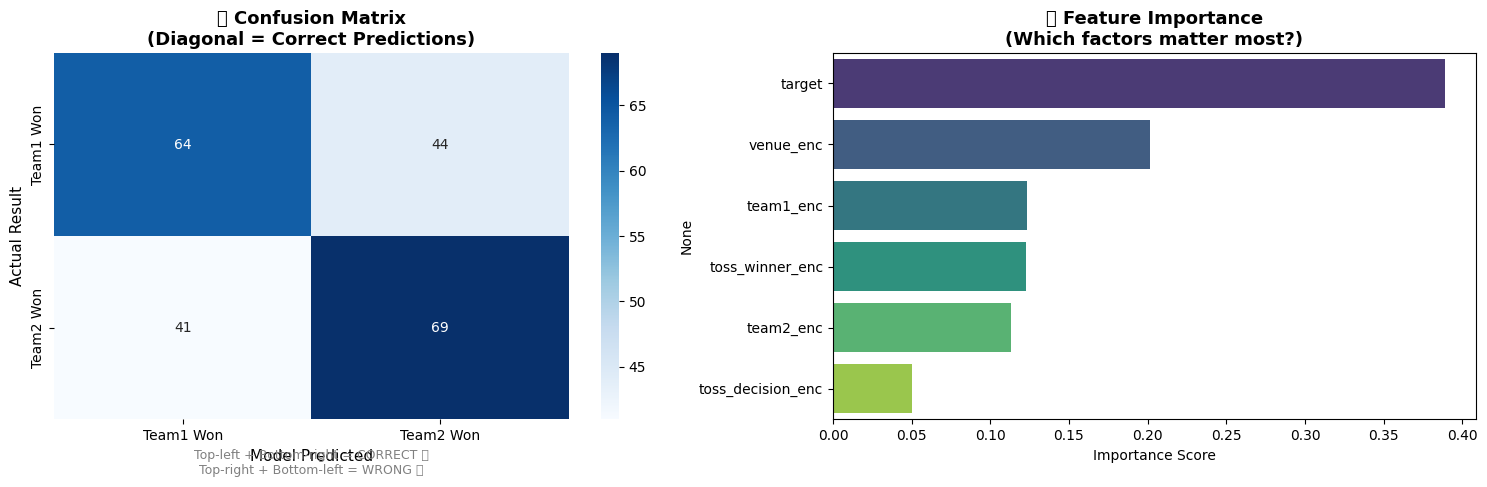


📖 Feature Importance Explanation:
Higher score = model relied on this feature more for predictions

Expected findings:
→ 'target' should be HIGH  (bigger target = harder to chase)
→ 'toss'   should be LOW   (we saw toss only matters 51% in Phase 1!)
→ 'teams'  should be MED   (team strength matters but not everything)


In [17]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Team1 Won', 'Team2 Won'],
            yticklabels=['Team1 Won', 'Team2 Won'],
            ax=axes[0])

axes[0].set_title('🎯 Confusion Matrix\n(Diagonal = Correct Predictions)', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Result', fontsize=11)
axes[0].set_xlabel('Model Predicted', fontsize=11)

axes[0].text(0.5, -0.15, 
             'Top-left + Bottom-right = CORRECT ✅\nTop-right + Bottom-left = WRONG ❌',
             transform=axes[0].transAxes, 
             ha='center', fontsize=9, color='gray')

feat_importance = pd.Series(final_model.feature_importances_,
                             index=features).sort_values(ascending=False)

sns.barplot(x=feat_importance.values,
            y=feat_importance.index,
            palette='viridis',
            ax=axes[1])

axes[1].set_title('🔍 Feature Importance\n(Which factors matter most?)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/processed/model_evaluation.png', dpi=150)
plt.show()

print("\n📖 Feature Importance Explanation:")
print("Higher score = model relied on this feature more for predictions")
print("\nExpected findings:")
print("→ 'target' should be HIGH  (bigger target = harder to chase)")
print("→ 'toss'   should be LOW   (we saw toss only matters 51% in Phase 1!)")
print("→ 'teams'  should be MED   (team strength matters but not everything)")

In [18]:
import pickle
import os

# Save directly with full path — no relative paths!
model_path    = r'C:\Users\harsh\ipl-analytics\src\model.pkl'
encoders_path = r'C:\Users\harsh\ipl-analytics\src\encoders.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

with open(encoders_path, 'wb') as f:
    pickle.dump({'team': le_team, 'venue': le_venue}, f)

# Verify files were actually created
print(f"model.pkl exists    : {os.path.exists(model_path)}")
print(f"encoders.pkl exists : {os.path.exists(encoders_path)}")
print(f"model.pkl size      : {os.path.getsize(model_path)} bytes")

model.pkl exists    : True
encoders.pkl exists : True
model.pkl size      : 1413654 bytes
